# Late-Payment Risk Model From Historical ERP/CRM Data

This notebook trains the Finplex AI late-payment risk model.

The model does not predict risk by looking up the uploaded invoice number. That would make the project useless because the uploaded invoice is supposed to be new.

Instead, the workflow is:

1. Notebook 1 creates new uploaded invoice images for existing customers.
2. Notebook 1 extracts customer and invoice details from those images.
3. Notebook 2 trains a risk model using historical ERP/CRM payment behavior.
4. The model predicts whether a new uploaded invoice is likely to be paid late based on the customer's previous behavior.

The model uses historical features such as:

- previous invoice count
- previous late payments
- average days late
- on-time payment rate
- disputed invoice history
- average invoice amount
- customer relationship age

The trained model will later be loaded by the model-server `/score-risk` endpoint.

## 1. Install Required Packages

This notebook uses:

- pandas and numpy for data processing;
- scikit-learn for model training;
- MLflow for experiment tracking;
- Comet ML for online experiment tracking and screenshots;
- matplotlib for plots;
- joblib for saving the trained model.

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib joblib mlflow comet_ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.6/796.6 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/

## 2. Import Libraries and Create Folders

The notebook loads seed files from Notebook 1, trains the risk model, logs experiments, and saves artifacts.

In [2]:
from pathlib import Path
from datetime import datetime, UTC
import json
import os
import shutil
import warnings
from zipfile import ZipFile

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from comet_ml import Experiment
from IPython.display import Image as DisplayImage
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
SEED_DIR = DATA_DIR / "seed"
MODELS_DIR = PROJECT_ROOT / "models"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "risk_model"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"

for folder in [
    SEED_DIR,
    MODELS_DIR,
    ARTIFACTS_DIR,
    MLRUNS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Seed folder:", SEED_DIR)
print("Models folder:", MODELS_DIR)
print("Artifacts folder:", ARTIFACTS_DIR)
print("MLflow folder:", MLRUNS_DIR)

Project root: /content
Seed folder: /content/data/seed
Models folder: /content/models
Artifacts folder: /content/artifacts/risk_model
MLflow folder: /content/mlruns


## 3. Load Seed Files From Notebook 1

This notebook depends on the seed files created by Notebook 1.

Required files:

- `data/seed/historical_erp_invoices.csv`
- `data/seed/historical_erp_payments.csv`
- `data/seed/crm_customers.csv`
- `data/seed/new_uploaded_invoice_ground_truth.csv`

If this notebook is running in a new Colab session, upload `invoice_extraction_artifacts.zip` from Notebook 1.

In [3]:
required_seed_files = [
    SEED_DIR / "historical_erp_invoices.csv",
    SEED_DIR / "historical_erp_payments.csv",
    SEED_DIR / "crm_customers.csv",
    SEED_DIR / "new_uploaded_invoice_ground_truth.csv",
]

missing_seed_files = [
    path
    for path in required_seed_files
    if not path.exists()
]

if missing_seed_files:
    print("Missing seed files:")
    for path in missing_seed_files:
        print("-", path)

    print("\nUpload invoice_extraction_artifacts.zip from Notebook 1.")

    try:
        from google.colab import files

        uploaded = files.upload()

        zip_files = [
            filename
            for filename in uploaded
            if filename.lower().endswith(".zip")
        ]

        if not zip_files:
            raise FileNotFoundError("No ZIP file was uploaded.")

        uploaded_zip_path = PROJECT_ROOT / zip_files[0]
        uploaded_zip_path.write_bytes(uploaded[zip_files[0]])

        with ZipFile(uploaded_zip_path, "r") as zip_ref:
            zip_ref.extractall(PROJECT_ROOT)

        print("Extracted:", uploaded_zip_path)

    except Exception as exc:
        raise RuntimeError(
            "Could not load the seed files. Upload the artifact ZIP from Notebook 1."
        ) from exc

for path in required_seed_files:
    if not path.exists():
        raise FileNotFoundError(f"Still missing required file: {path}")

print("All required seed files are available.")

Missing seed files:
- /content/data/seed/historical_erp_invoices.csv
- /content/data/seed/historical_erp_payments.csv
- /content/data/seed/crm_customers.csv
- /content/data/seed/new_uploaded_invoice_ground_truth.csv

Upload invoice_extraction_artifacts.zip from Notebook 1.


Saving invoice_extraction_artifacts.zip to invoice_extraction_artifacts.zip
Extracted: /content/invoice_extraction_artifacts.zip
All required seed files are available.


## 4. Read Historical ERP, Payment, CRM, and New Invoice Data

The historical ERP/CRM files are used for training.

The new uploaded invoice file is used later to test the prediction flow.

In [4]:
historical_invoices_path = SEED_DIR / "historical_erp_invoices.csv"
historical_payments_path = SEED_DIR / "historical_erp_payments.csv"
crm_customers_path = SEED_DIR / "crm_customers.csv"
new_uploaded_invoices_path = SEED_DIR / "new_uploaded_invoice_ground_truth.csv"

historical_invoices_df = pd.read_csv(historical_invoices_path)
historical_payments_df = pd.read_csv(historical_payments_path)
crm_customers_df = pd.read_csv(crm_customers_path)
new_uploaded_invoices_df = pd.read_csv(new_uploaded_invoices_path)

print("Historical invoices:", historical_invoices_df.shape)
print("Historical payments:", historical_payments_df.shape)
print("CRM customers:", crm_customers_df.shape)
print("New uploaded invoices:", new_uploaded_invoices_df.shape)

display(historical_invoices_df.head())
display(crm_customers_df.head())
display(new_uploaded_invoices_df.head())

Historical invoices: (2466, 18)
Historical payments: (2466, 8)
CRM customers: (100, 16)
New uploaded invoices: (40, 13)


,tenant_id,historical_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,invoice_date,due_date,payment_terms_days,amount_due,currency,country_code,is_disputed,paperless_bill,settled_date,days_to_settle,days_late,days_overdue
0,tenant_demo,hist_inv_00991,4037644863,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-03-29,2012-04-28,30,62.68,USD,391,1,0,2012-04-25,27,0,0
1,tenant_demo,hist_inv_02345,9471530987,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-15,2012-06-14,30,77.19,USD,391,0,0,2012-05-28,13,0,0
2,tenant_demo,hist_inv_02401,9744145268,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-21,2012-06-20,30,51.65,USD,391,0,0,2012-06-04,14,0,0
3,tenant_demo,hist_inv_01791,7214076449,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-06-16,2012-07-16,30,64.47,USD,391,1,0,2012-07-04,18,0,0
4,tenant_demo,hist_inv_00445,1756742390,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-09-05,2012-10-05,30,84.57,USD,391,0,0,2012-09-14,9,0,0


,tenant_id,finplex_customer_id,external_customer_id,customer_name,country_code,historical_invoice_count,total_historical_amount,average_invoice_amount,previous_late_payments,average_days_late,max_days_late,disputed_invoice_count,paperless_bill_rate,on_time_payment_rate,crm_negative_signal_score,relationship_age_days
0,tenant_demo,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,391,16,1072.63,67.039375,0,0.000000,0,7,0.0,1.000,0.438,845
1,tenant_demo,cust_0379-NEVHP,0379-NEVHP,Customer 0379-NEVHP,391,27,1584.18,58.673333,1,0.629630,17,2,0.0,0.963,0.111,1175
2,tenant_demo,cust_0465-DTULQ,0465-DTULQ,Customer 0465-DTULQ,770,26,1360.12,52.312308,14,5.307692,21,8,0.0,0.462,0.846,1145
3,tenant_demo,cust_0625-TNJFG,0625-TNJFG,Customer 0625-TNJFG,770,28,1627.26,58.116429,5,0.714286,11,1,0.0,0.821,0.214,1205
4,tenant_demo,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,34,1231.45,36.219118,32,14.441176,34,5,0.0,0.059,1.000,1385


,tenant_id,new_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,country_code,invoice_date,due_date,payment_terms_days,amount_due,currency,image_path
0,tenant_demo,new_inv_00001,NEW-00001,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,2014-01-01,2014-03-02,60,50.00,USD,/content/data/demo_invoices/new_uploaded_invoi...
1,tenant_demo,new_inv_00002,NEW-00002,cust_8690-EEBEO,8690-EEBEO,Customer 8690-EEBEO,897,2014-01-02,2014-02-01,30,72.74,USD,/content/data/demo_invoices/new_uploaded_invoi...
2,tenant_demo,new_inv_00003,NEW-00003,cust_8102-ABPKQ,8102-ABPKQ,Customer 8102-ABPKQ,818,2014-01-03,2014-02-02,30,55.65,USD,/content/data/demo_invoices/new_uploaded_invoi...
3,tenant_demo,new_inv_00004,NEW-00004,cust_6708-DPYTF,6708-DPYTF,Customer 6708-DPYTF,391,2014-01-04,2014-02-18,45,62.90,USD,/content/data/demo_invoices/new_uploaded_invoi...
4,tenant_demo,new_inv_00005,NEW-00005,cust_4460-ZXNDN,4460-ZXNDN,Customer 4460-ZXNDN,770,2014-01-05,2014-02-19,45,77.88,USD,/content/data/demo_invoices/new_uploaded_invoi...


## 5. Clean Data Types

This step prepares dates, numerical columns, and binary columns before feature engineering.

In [5]:
def clean_numeric_column(df: pd.DataFrame, column_name: str, default_value=0) -> pd.Series:
    return pd.to_numeric(
        df[column_name],
        errors="coerce",
    ).fillna(default_value)


historical_invoices_df["invoice_date"] = pd.to_datetime(
    historical_invoices_df["invoice_date"],
    errors="coerce",
)

historical_invoices_df["due_date"] = pd.to_datetime(
    historical_invoices_df["due_date"],
    errors="coerce",
)

historical_invoices_df["settled_date"] = pd.to_datetime(
    historical_invoices_df["settled_date"],
    errors="coerce",
)

historical_invoices_df["amount_due"] = clean_numeric_column(
    historical_invoices_df,
    "amount_due",
    0,
)

historical_invoices_df["payment_terms_days"] = clean_numeric_column(
    historical_invoices_df,
    "payment_terms_days",
    30,
).astype(int)

historical_invoices_df["paperless_bill"] = clean_numeric_column(
    historical_invoices_df,
    "paperless_bill",
    0,
).astype(int)

historical_invoices_df["is_disputed"] = clean_numeric_column(
    historical_invoices_df,
    "is_disputed",
    0,
).astype(int)

historical_invoices_df["days_late"] = clean_numeric_column(
    historical_invoices_df,
    "days_late",
    0,
).astype(int)

historical_invoices_df["days_overdue"] = historical_invoices_df["days_late"].clip(
    lower=0
)

historical_invoices_df["country_code"] = (
    historical_invoices_df["country_code"]
    .astype(str)
    .str.strip()
)

historical_invoices_df["finplex_customer_id"] = (
    historical_invoices_df["finplex_customer_id"]
    .astype(str)
    .str.strip()
)

historical_invoices_df = historical_invoices_df.dropna(
    subset=[
        "invoice_date",
        "due_date",
        "finplex_customer_id",
        "amount_due",
    ]
).copy()

historical_invoices_df = historical_invoices_df[
    historical_invoices_df["amount_due"] > 0
].copy()

historical_invoices_df = historical_invoices_df.sort_values(
    [
        "finplex_customer_id",
        "invoice_date",
        "invoice_number",
    ]
).reset_index(drop=True)

print("Clean historical invoice rows:", len(historical_invoices_df))
display(historical_invoices_df.head())

Clean historical invoice rows: 2466


,tenant_id,historical_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,invoice_date,due_date,payment_terms_days,amount_due,currency,country_code,is_disputed,paperless_bill,settled_date,days_to_settle,days_late,days_overdue
0,tenant_demo,hist_inv_00991,4037644863,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-03-29,2012-04-28,30,62.68,USD,391,1,0,2012-04-25,27,0,0
1,tenant_demo,hist_inv_02345,9471530987,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-15,2012-06-14,30,77.19,USD,391,0,0,2012-05-28,13,0,0
2,tenant_demo,hist_inv_02401,9744145268,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-21,2012-06-20,30,51.65,USD,391,0,0,2012-06-04,14,0,0
3,tenant_demo,hist_inv_01791,7214076449,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-06-16,2012-07-16,30,64.47,USD,391,1,0,2012-07-04,18,0,0
4,tenant_demo,hist_inv_00445,1756742390,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-09-05,2012-10-05,30,84.57,USD,391,0,0,2012-09-14,9,0,0


## 6. Create Risk Labels From Historical Payment Behavior

The target label is created from `days_late`.

The model predicts the late-payment risk class:

- `low`: paid on time or almost on time
- `medium`: slightly late
- `high`: clearly late
- `critical`: very late

This target is based on historical payment outcomes only.

,count
risk_label,
high,174
low,1589
medium,703


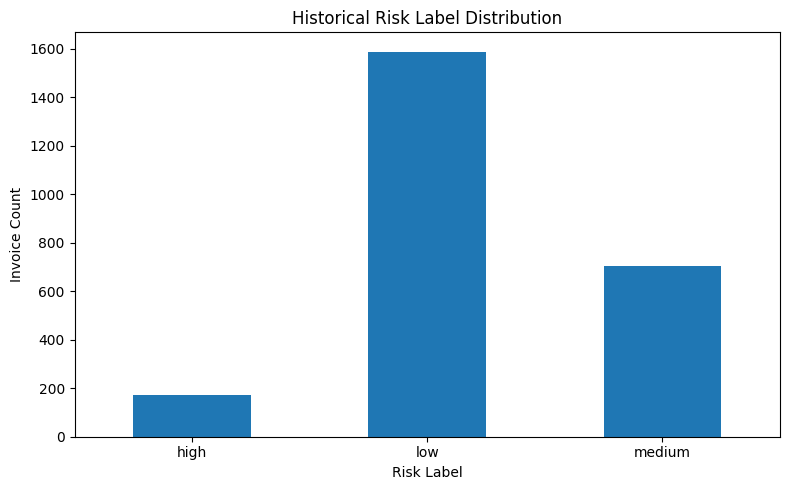

In [6]:
def days_late_to_risk_label(days_late: int) -> str:
    if days_late <= 0:
        return "low"

    if days_late <= 15:
        return "medium"

    if days_late <= 45:
        return "high"

    return "critical"


historical_invoices_df["risk_label"] = historical_invoices_df["days_late"].apply(
    days_late_to_risk_label
)

label_distribution = historical_invoices_df["risk_label"].value_counts().sort_index()

display(label_distribution.to_frame(name="count"))

plt.figure(figsize=(8, 5))
label_distribution.plot(kind="bar")
plt.title("Historical Risk Label Distribution")
plt.xlabel("Risk Label")
plt.ylabel("Invoice Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Build Leakage-Safe Customer History Features

This is the most important part of Notebook 2.

For each historical invoice, the model should only use customer behavior that happened before that invoice.

For example, when training on invoice number 10 for a customer, the model can use invoices 1 to 9 as previous behavior, but it should not use invoice 10's own payment outcome as an input feature.

This avoids data leakage.

In [7]:
feature_df = historical_invoices_df.copy()

feature_df["was_late"] = (feature_df["days_late"] > 0).astype(int)

feature_df["previous_invoice_count"] = (
    feature_df.groupby("finplex_customer_id").cumcount()
)

feature_df["previous_late_payments"] = (
    feature_df.groupby("finplex_customer_id")["was_late"]
    .cumsum()
    - feature_df["was_late"]
)

feature_df["previous_disputed_count"] = (
    feature_df.groupby("finplex_customer_id")["is_disputed"]
    .cumsum()
    - feature_df["is_disputed"]
)

feature_df["previous_total_amount"] = (
    feature_df.groupby("finplex_customer_id")["amount_due"]
    .cumsum()
    - feature_df["amount_due"]
)

feature_df["previous_average_invoice_amount"] = (
    feature_df["previous_total_amount"]
    / feature_df["previous_invoice_count"].replace(0, np.nan)
).fillna(feature_df["amount_due"])

feature_df["previous_days_late_sum"] = (
    feature_df.groupby("finplex_customer_id")["days_late"]
    .cumsum()
    - feature_df["days_late"]
)

feature_df["previous_average_days_late"] = (
    feature_df["previous_days_late_sum"]
    / feature_df["previous_invoice_count"].replace(0, np.nan)
).fillna(0)

feature_df["previous_max_days_late"] = (
    feature_df.groupby("finplex_customer_id")["days_late"]
    .transform(lambda values: values.shift().cummax())
    .fillna(0)
)

feature_df["previous_on_time_payment_rate"] = (
    1
    - (
        feature_df["previous_late_payments"]
        / feature_df["previous_invoice_count"].replace(0, np.nan)
    )
).fillna(1.0)

feature_df["previous_dispute_rate"] = (
    feature_df["previous_disputed_count"]
    / feature_df["previous_invoice_count"].replace(0, np.nan)
).fillna(0)

feature_df["previous_crm_negative_signal_score"] = (
    (
        feature_df["previous_late_payments"]
        + feature_df["previous_disputed_count"]
    )
    / feature_df["previous_invoice_count"].replace(0, np.nan)
).fillna(0).clip(0, 1)

first_invoice_date_by_customer = feature_df.groupby("finplex_customer_id")[
    "invoice_date"
].transform("min")

feature_df["relationship_age_days"] = (
    feature_df["invoice_date"] - first_invoice_date_by_customer
).dt.days.clip(lower=0)

feature_df.head()

,tenant_id,historical_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,invoice_date,due_date,payment_terms_days,amount_due,...,previous_disputed_count,previous_total_amount,previous_average_invoice_amount,previous_days_late_sum,previous_average_days_late,previous_max_days_late,previous_on_time_payment_rate,previous_dispute_rate,previous_crm_negative_signal_score,relationship_age_days
0,tenant_demo,hist_inv_00991,4037644863,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-03-29,2012-04-28,30,62.68,...,0,0.00,62.6800,0,0.0,0.0,1.0,0.000000,0.000000,0
1,tenant_demo,hist_inv_02345,9471530987,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-15,2012-06-14,30,77.19,...,1,62.68,62.6800,0,0.0,0.0,1.0,1.000000,1.000000,47
2,tenant_demo,hist_inv_02401,9744145268,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-21,2012-06-20,30,51.65,...,1,139.87,69.9350,0,0.0,0.0,1.0,0.500000,0.500000,53
3,tenant_demo,hist_inv_01791,7214076449,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-06-16,2012-07-16,30,64.47,...,1,191.52,63.8400,0,0.0,0.0,1.0,0.333333,0.333333,79
4,tenant_demo,hist_inv_00445,1756742390,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-09-05,2012-10-05,30,84.57,...,2,255.99,63.9975,0,0.0,0.0,1.0,0.500000,0.500000,160


## 8. Create the Final Training Dataset

The final training dataset includes:

- current invoice fields known at invoice time;
- previous customer behavior;
- country/customer context;
- target risk label.

It does not include the current invoice's `days_late` as an input feature because that is the outcome we are trying to predict.

In [8]:
TRAINING_MIN_PREVIOUS_INVOICES = 1

training_df = feature_df[
    feature_df["previous_invoice_count"] >= TRAINING_MIN_PREVIOUS_INVOICES
].copy()

FEATURE_COLUMNS = [
    "amount_due",
    "payment_terms_days",
    "paperless_bill",
    "country_code",
    "previous_invoice_count",
    "previous_late_payments",
    "previous_disputed_count",
    "previous_total_amount",
    "previous_average_invoice_amount",
    "previous_average_days_late",
    "previous_max_days_late",
    "previous_on_time_payment_rate",
    "previous_dispute_rate",
    "previous_crm_negative_signal_score",
    "relationship_age_days",
]

TARGET_COLUMN = "risk_label"

model_training_df = training_df[
    FEATURE_COLUMNS + [TARGET_COLUMN]
].copy()

risk_training_dataset_path = SEED_DIR / "risk_training_dataset.csv"
model_training_df.to_csv(risk_training_dataset_path, index=False)

print("Training rows:", len(model_training_df))
print("Saved training dataset:", risk_training_dataset_path)

display(model_training_df.head())
display(model_training_df[TARGET_COLUMN].value_counts().sort_index().to_frame("count"))

Training rows: 2366
Saved training dataset: /content/data/seed/risk_training_dataset.csv


,amount_due,payment_terms_days,paperless_bill,country_code,previous_invoice_count,previous_late_payments,previous_disputed_count,previous_total_amount,previous_average_invoice_amount,previous_average_days_late,previous_max_days_late,previous_on_time_payment_rate,previous_dispute_rate,previous_crm_negative_signal_score,relationship_age_days,risk_label
1,77.19,30,0,391,1,0,1,62.68,62.6800,0.0,0.0,1.0,1.000000,1.000000,47,low
2,51.65,30,0,391,2,0,1,139.87,69.9350,0.0,0.0,1.0,0.500000,0.500000,53,low
3,64.47,30,0,391,3,0,1,191.52,63.8400,0.0,0.0,1.0,0.333333,0.333333,79,low
4,84.57,30,0,391,4,0,2,255.99,63.9975,0.0,0.0,1.0,0.500000,0.500000,160,low
5,65.26,30,0,391,5,0,2,340.56,68.1120,0.0,0.0,1.0,0.400000,0.400000,177,low


,count
risk_label,
high,168
low,1530
medium,668


## 9. Split Features and Target

The model is trained on historical ERP/CRM features and evaluated on a held-out test set.

In [9]:
X = model_training_df[FEATURE_COLUMNS].copy()
y = model_training_df[TARGET_COLUMN].copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

class_counts = y.value_counts()
can_stratify = class_counts.min() >= 2 and len(class_counts) > 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y if can_stratify else None,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Can stratify:", can_stratify)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Training rows: 1892
Test rows: 474
Can stratify: True
Numeric features: ['amount_due', 'payment_terms_days', 'paperless_bill', 'previous_invoice_count', 'previous_late_payments', 'previous_disputed_count', 'previous_total_amount', 'previous_average_invoice_amount', 'previous_average_days_late', 'previous_max_days_late', 'previous_on_time_payment_rate', 'previous_dispute_rate', 'previous_crm_negative_signal_score', 'relationship_age_days']
Categorical features: ['country_code']


## 10. Configure Online Comet Tracking and Local MLflow Tracking

This notebook uses two tracking layers:

1. MLflow local tracking, saved inside the notebook artifacts.
2. Comet ML online tracking, so I can log in online, view experiment results, and take a screenshot.

To use Comet online tracking, add a Colab secret named:

`COMET_API_KEY`

Optionally add:

`COMET_WORKSPACE`

If no Comet key is available, the notebook still trains and logs local MLflow runs.

In [11]:
def load_colab_secret(secret_name: str) -> str | None:
    try:
        from google.colab import userdata

        value = userdata.get(secret_name)

        if value:
            return value

    except Exception:
        pass

    return os.getenv(secret_name)


COMET_API_KEY = load_colab_secret("COMET_API_KEY")
COMET_WORKSPACE = load_colab_secret("COMET_WORKSPACE")

COMET_PROJECT_NAME = "finplex-ai-risk-model"

USE_COMET = COMET_API_KEY is not None and len(str(COMET_API_KEY).strip()) > 0

# New MLflow versions recommend a database backend instead of file://mlruns.
# SQLite is simple and works well inside Colab/local notebooks.
MLFLOW_DB_PATH = PROJECT_ROOT / "mlflow.db"
MLFLOW_ARTIFACTS_DIR = PROJECT_ROOT / "mlflow_artifacts"

MLFLOW_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")
mlflow.set_experiment("finplex_late_payment_risk_model")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow database path:", MLFLOW_DB_PATH)
print("MLflow artifacts folder:", MLFLOW_ARTIFACTS_DIR)

if USE_COMET:
    print("Comet online tracking is enabled.")
    print("Comet project name:", COMET_PROJECT_NAME)
else:
    print("Comet online tracking is not enabled.")
    print("Add COMET_API_KEY in Colab Secrets to log experiments online.")

2026/06/18 15:20:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/18 15:20:08 INFO mlflow.store.db.utils: Updating database tables
2026/06/18 15:20:11 INFO mlflow.tracking.fluent: Experiment with name 'finplex_late_payment_risk_model' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////content/mlflow.db
MLflow database path: /content/mlflow.db
MLflow artifacts folder: /content/mlflow_artifacts
Comet online tracking is enabled.
Comet project name: finplex-ai-risk-model


## 11. Build Model Pipelines

The notebook compares multiple candidate models.

The preprocessing pipeline handles numerical and categorical features.

In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

candidate_models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_SEED,
    ),
}

candidate_models

{'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'random_forest': RandomForestClassifier(class_weight='balanced', max_depth=12,
                        min_samples_leaf=4, n_estimators=250, n_jobs=-1,
                        random_state=42),
 'gradient_boosting': GradientBoostingClassifier(random_state=42)}

## 12. Helper Functions for Experiment Logging

These helper functions train a model, evaluate it, log results to MLflow, and optionally log results to Comet ML online.

In [17]:
LABEL_ORDER = ["low", "medium", "high", "critical"]


def save_json(data: dict, path: Path) -> None:
    path.write_text(
        json.dumps(data, indent=2),
        encoding="utf-8",
    )


def log_to_comet(
    model_name: str,
    metrics: dict,
    params: dict,
    report_path: Path,
    model_artifact_path: Path,
) -> str | None:
    if not USE_COMET:
        return None

    experiment = Experiment(
        api_key=COMET_API_KEY,
        project_name=COMET_PROJECT_NAME,
        workspace=COMET_WORKSPACE,
        auto_param_logging=False,
        auto_metric_logging=False,
        auto_output_logging="simple",
    )

    experiment.set_name(model_name)
    experiment.log_parameters(params)
    experiment.log_metrics(metrics)
    experiment.log_asset(str(report_path))
    experiment.log_asset(str(model_artifact_path))

    comet_url = experiment.url

    experiment.end()

    return comet_url


def train_and_evaluate_model(model_name: str, estimator) -> dict:
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)
        macro_f1 = f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        )
        weighted_f1 = f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0,
        )

        report = classification_report(
            y_test,
            predictions,
            output_dict=True,
            zero_division=0,
        )

        report_path = ARTIFACTS_DIR / f"{model_name}_classification_report.json"
        save_json(report, report_path)

        model_artifact_path = ARTIFACTS_DIR / f"{model_name}_pipeline.joblib"
        joblib.dump(pipeline, model_artifact_path)

        params = {
            "model_name": model_name,
            "training_rows": len(X_train),
            "test_rows": len(X_test),
            "feature_count": len(FEATURE_COLUMNS),
            "target_column": TARGET_COLUMN,
        }

        metrics = {
            "accuracy": float(accuracy),
            "macro_f1": float(macro_f1),
            "weighted_f1": float(weighted_f1),
        }

        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.log_artifact(str(report_path))
        mlflow.log_artifact(str(model_artifact_path))

        comet_url = log_to_comet(
            model_name=model_name,
            metrics=metrics,
            params=params,
            report_path=report_path,
            model_artifact_path=model_artifact_path,
        )

        return {
            "model_name": model_name,
            "pipeline": pipeline,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "classification_report": report,
            "report_path": str(report_path),
            "model_artifact_path": str(model_artifact_path),
            "comet_url": comet_url,
        }

## 13. Train and Compare Models

This section trains all candidate models and compares their metrics.

Macro F1 is important because it treats all risk classes fairly instead of focusing only on the majority class.

In [18]:
model_results = []

for model_name, estimator in candidate_models.items():
    print(f"Training {model_name}...")
    result = train_and_evaluate_model(model_name, estimator)
    model_results.append(result)

results_summary_df = pd.DataFrame(
    [
        {
            "model_name": result["model_name"],
            "accuracy": result["accuracy"],
            "macro_f1": result["macro_f1"],
            "weighted_f1": result["weighted_f1"],
            "comet_url": result["comet_url"],
        }
        for result in model_results
    ]
).sort_values("macro_f1", ascending=False)

results_summary_path = ARTIFACTS_DIR / "risk_model_results_summary.csv"
results_summary_df.to_csv(results_summary_path, index=False)

display(results_summary_df)
print("Saved results summary:", results_summary_path)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: mlflow.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


Training logistic_regression...


COMET INFO: Experiment is live on comet.com https://www.comet.com/hussein-shiri/finplex-ai-risk-model/1c9f8ba9b7df4d07853eaf5b0f7aacfd

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : logistic_regression
COMET INFO:     url                   : https://www.comet.com/hussein-shiri/finplex-ai-risk-model/1c9f8ba9b7df4d07853eaf5b0f7aacfd
COMET INFO:   Metrics:
COMET INFO:     accuracy    : 0.6919831223628692
COMET INFO:     macro_f1    : 0.5761854502639819
COMET INFO:     weighted_f1 : 0.7095738256345592
COMET INFO:   Others:
COMET INFO:     Name         :

Training random_forest...


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: mlflow.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/hussein-shiri/finplex-ai-risk-model/c12112a0afd1488d9c33013a9b485fa6

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : random_forest
COMET INFO:     url                   : https://www.comet.com/hussein-shiri/fin

Training gradient_boosting...


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: mlflow.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/hussein-shiri/finplex-ai-risk-model/f0bf2c86749645d59d5d88b9ce1ab910

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : gradient_boosting
COMET INFO:     url                   : https://www.comet.com/hussein-shiri

,model_name,accuracy,macro_f1,weighted_f1,comet_url
0,logistic_regression,0.691983,0.576185,0.709574,https://www.comet.com/hussein-shiri/finplex-ai...
1,random_forest,0.723629,0.565574,0.729075,https://www.comet.com/hussein-shiri/finplex-ai...
2,gradient_boosting,0.736287,0.473591,0.713007,https://www.comet.com/hussein-shiri/finplex-ai...


Saved results summary: /content/artifacts/risk_model/risk_model_results_summary.csv


## 14. Select the Best Model

The best model is selected using macro F1.

This is better than accuracy alone because late-payment risk classes may be imbalanced.

In [19]:
best_result = max(
    model_results,
    key=lambda result: result["macro_f1"],
)

best_model_name = best_result["model_name"]
best_model = best_result["pipeline"]
best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Accuracy:", round(best_result["accuracy"], 4))
print("Macro F1:", round(best_result["macro_f1"], 4))
print("Weighted F1:", round(best_result["weighted_f1"], 4))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0,
    )
)

Best model: logistic_regression
Accuracy: 0.692
Macro F1: 0.5762
Weighted F1: 0.7096

Classification report:
              precision    recall  f1-score   support

        high       0.28      0.68      0.39        34
         low       0.89      0.79      0.84       306
      medium       0.53      0.47      0.50       134

    accuracy                           0.69       474
   macro avg       0.57      0.65      0.58       474
weighted avg       0.74      0.69      0.71       474



## 15. Plot the Confusion Matrix

The confusion matrix shows where the model predicts each risk class correctly and where it makes mistakes.

,predicted_low,predicted_medium,predicted_high,predicted_critical
actual_low,242,46,18,0
actual_medium,29,63,42,0
actual_high,1,10,23,0
actual_critical,0,0,0,0


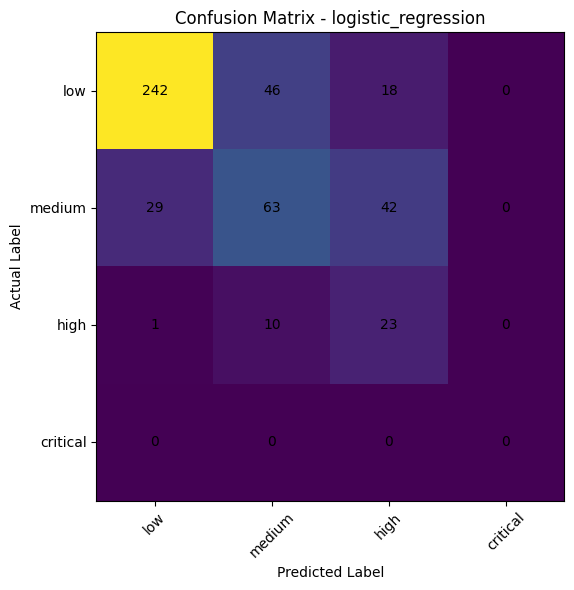

Saved confusion matrix: /content/artifacts/risk_model/risk_model_confusion_matrix.png


In [20]:
cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=LABEL_ORDER,
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"actual_{label}" for label in LABEL_ORDER],
    columns=[f"predicted_{label}" for label in LABEL_ORDER],
)

display(confusion_matrix_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=45)
plt.yticks(range(len(LABEL_ORDER)), LABEL_ORDER)

for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        plt.text(
            col_index,
            row_index,
            cm[row_index, col_index],
            ha="center",
            va="center",
        )

plt.tight_layout()

confusion_matrix_path = ARTIFACTS_DIR / "risk_model_confusion_matrix.png"
plt.savefig(confusion_matrix_path, bbox_inches="tight")
plt.show()

print("Saved confusion matrix:", confusion_matrix_path)

## 16. Inspect Feature Importance

Feature importance helps explain which ERP/CRM signals affect risk prediction most.

Tree models provide feature importance directly. Logistic regression provides coefficient strength.

,feature,importance
14,country_code_391,0.403512
10,previous_on_time_payment_rate,0.346899
8,previous_average_days_late,0.246667
0,amount_due,0.219133
3,previous_invoice_count,0.202058
9,previous_max_days_late,0.184005
12,previous_crm_negative_signal_score,0.167682
17,country_code_818,0.163170
4,previous_late_payments,0.147325
18,country_code_897,0.125467


<Figure size 900x600 with 0 Axes>

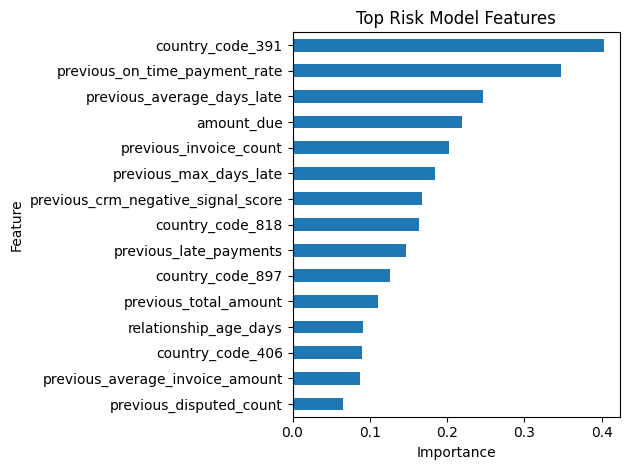

Saved feature importance CSV: /content/artifacts/risk_model/risk_model_feature_importance.csv
Saved feature importance plot: /content/artifacts/risk_model/risk_model_feature_importance.png


In [21]:
def get_transformed_feature_names(model_pipeline: Pipeline) -> list[str]:
    fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

    feature_names = []

    feature_names.extend(numeric_features)

    if categorical_features:
        onehot = fitted_preprocessor.named_transformers_["categorical"].named_steps[
            "onehot"
        ]
        categorical_names = onehot.get_feature_names_out(
            categorical_features
        ).tolist()
        feature_names.extend(categorical_names)

    return feature_names


feature_names = get_transformed_feature_names(best_model)
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importance_values = model_step.feature_importances_

elif hasattr(model_step, "coef_"):
    importance_values = np.abs(model_step.coef_).mean(axis=0)

else:
    importance_values = np.zeros(len(feature_names))

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importance_values,
    }
).sort_values("importance", ascending=False)

feature_importance_path = ARTIFACTS_DIR / "risk_model_feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

display(feature_importance_df.head(20))

plt.figure(figsize=(9, 6))
feature_importance_df.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
)
plt.title("Top Risk Model Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_importance_plot_path = ARTIFACTS_DIR / "risk_model_feature_importance.png"
plt.savefig(feature_importance_plot_path, bbox_inches="tight")
plt.show()

print("Saved feature importance CSV:", feature_importance_path)
print("Saved feature importance plot:", feature_importance_plot_path)

## 17. Save the Final Model Artifacts

The best model is saved as a `.joblib` file.

The model-server can later load this file and use it inside the `/score-risk` endpoint.

In [22]:
model_path = MODELS_DIR / "risk_model.joblib"
label_mapping_path = MODELS_DIR / "risk_label_mapping.json"
model_metadata_path = MODELS_DIR / "risk_model_metadata.json"
feature_schema_path = MODELS_DIR / "risk_feature_schema.json"

joblib.dump(best_model, model_path)

label_mapping = {
    "labels": LABEL_ORDER,
    "target_column": TARGET_COLUMN,
}

feature_schema = {
    "feature_columns": FEATURE_COLUMNS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
}

model_metadata = {
    "model_name": best_model_name,
    "created_at": datetime.now(UTC).isoformat(),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "features": FEATURE_COLUMNS,
    "target": TARGET_COLUMN,
    "metrics": {
        "accuracy": float(best_result["accuracy"]),
        "macro_f1": float(best_result["macro_f1"]),
        "weighted_f1": float(best_result["weighted_f1"]),
    },
    "artifact": str(model_path),
    "online_tracking": {
        "tool": "Comet ML",
        "enabled": bool(USE_COMET),
        "project_name": COMET_PROJECT_NAME,
    },
}

save_json(label_mapping, label_mapping_path)
save_json(model_metadata, model_metadata_path)
save_json(feature_schema, feature_schema_path)

print("Saved model:", model_path)
print("Saved label mapping:", label_mapping_path)
print("Saved model metadata:", model_metadata_path)
print("Saved feature schema:", feature_schema_path)

Saved model: /content/models/risk_model.joblib
Saved label mapping: /content/models/risk_label_mapping.json
Saved model metadata: /content/models/risk_model_metadata.json
Saved feature schema: /content/models/risk_feature_schema.json


## 18. Build Features for New Uploaded Invoices

This section simulates the real app flow.

The new uploaded invoice is not in historical ERP data. The system uses the extracted customer ID to retrieve historical CRM behavior, then builds the risk model input features.

In [23]:
def get_customer_history_for_prediction(
    customer_id: str,
    crm_df: pd.DataFrame,
) -> dict:
    matched_rows = crm_df[
        crm_df["finplex_customer_id"].astype(str).str.lower()
        == str(customer_id).lower()
    ]

    if len(matched_rows) == 0:
        return {}

    row = matched_rows.iloc[0]

    previous_invoice_count = int(row.get("historical_invoice_count", 0))
    previous_late_payments = int(row.get("previous_late_payments", 0))
    previous_disputed_count = int(row.get("disputed_invoice_count", 0))

    previous_total_amount = float(row.get("total_historical_amount", 0))
    previous_average_invoice_amount = float(row.get("average_invoice_amount", 0))
    previous_average_days_late = float(row.get("average_days_late", 0))
    previous_max_days_late = float(row.get("max_days_late", 0))

    previous_on_time_payment_rate = float(row.get("on_time_payment_rate", 1.0))
    previous_crm_negative_signal_score = float(
        row.get("crm_negative_signal_score", 0)
    )
    relationship_age_days = int(row.get("relationship_age_days", 0))

    previous_dispute_rate = (
        previous_disputed_count / previous_invoice_count
        if previous_invoice_count > 0
        else 0
    )

    return {
        "previous_invoice_count": previous_invoice_count,
        "previous_late_payments": previous_late_payments,
        "previous_disputed_count": previous_disputed_count,
        "previous_total_amount": previous_total_amount,
        "previous_average_invoice_amount": previous_average_invoice_amount,
        "previous_average_days_late": previous_average_days_late,
        "previous_max_days_late": previous_max_days_late,
        "previous_on_time_payment_rate": previous_on_time_payment_rate,
        "previous_dispute_rate": previous_dispute_rate,
        "previous_crm_negative_signal_score": previous_crm_negative_signal_score,
        "relationship_age_days": relationship_age_days,
    }


def build_prediction_features_for_new_invoice(
    invoice_row: pd.Series,
    crm_df: pd.DataFrame,
) -> dict:
    customer_history = get_customer_history_for_prediction(
        customer_id=invoice_row["finplex_customer_id"],
        crm_df=crm_df,
    )

    if not customer_history:
        raise ValueError(
            f"No CRM history found for customer {invoice_row['finplex_customer_id']}"
        )

    feature_row = {
        "amount_due": float(invoice_row["amount_due"]),
        "payment_terms_days": int(invoice_row["payment_terms_days"]),
        "paperless_bill": 0,
        "country_code": str(invoice_row["country_code"]),
    }

    feature_row.update(customer_history)

    return feature_row


new_prediction_rows = []

for _, invoice_row in new_uploaded_invoices_df.iterrows():
    try:
        feature_row = build_prediction_features_for_new_invoice(
            invoice_row=invoice_row,
            crm_df=crm_customers_df,
        )

        feature_row["new_invoice_id"] = invoice_row["new_invoice_id"]
        feature_row["invoice_number"] = invoice_row["invoice_number"]
        feature_row["finplex_customer_id"] = invoice_row["finplex_customer_id"]
        feature_row["customer_name"] = invoice_row["customer_name"]

        new_prediction_rows.append(feature_row)

    except Exception as exc:
        print("Skipping invoice:", invoice_row.get("invoice_number"), exc)

new_prediction_features_df = pd.DataFrame(new_prediction_rows)

display(new_prediction_features_df.head())
print("New invoice prediction rows:", len(new_prediction_features_df))

,amount_due,payment_terms_days,paperless_bill,country_code,previous_invoice_count,previous_late_payments,previous_disputed_count,previous_total_amount,previous_average_invoice_amount,previous_average_days_late,previous_max_days_late,previous_on_time_payment_rate,previous_dispute_rate,previous_crm_negative_signal_score,relationship_age_days,new_invoice_id,invoice_number,finplex_customer_id,customer_name
0,50.00,60,0,897,34,32,5,1231.45,36.219118,14.441176,34.0,0.059,0.147059,1.000,1385,new_inv_00001,NEW-00001,cust_0688-XNJRO,Customer 0688-XNJRO
1,72.74,30,0,897,31,26,1,1875.18,60.489677,7.387097,27.0,0.161,0.032258,0.871,1295,new_inv_00002,NEW-00002,cust_8690-EEBEO,Customer 8690-EEBEO
2,55.65,30,0,818,27,26,23,1696.26,62.824444,14.592593,26.0,0.037,0.851852,1.000,1175,new_inv_00003,NEW-00003,cust_8102-ABPKQ,Customer 8102-ABPKQ
3,62.90,45,0,391,30,25,0,2268.28,75.609333,7.766667,17.0,0.167,0.000000,0.833,1265,new_inv_00004,NEW-00004,cust_6708-DPYTF,Customer 6708-DPYTF
4,77.88,45,0,770,28,25,14,1928.71,68.882500,12.285714,34.0,0.107,0.500000,1.000,1205,new_inv_00005,NEW-00005,cust_4460-ZXNDN,Customer 4460-ZXNDN


New invoice prediction rows: 40


## 19. Predict Risk for New Uploaded Invoices

This step proves that Notebook 1 and Notebook 2 are connected.

Notebook 1 created new uploaded invoices for existing customers. Notebook 2 uses those customer IDs to find historical behavior and predict risk.

In [24]:
loaded_model = joblib.load(model_path)

new_invoice_model_input_df = new_prediction_features_df[FEATURE_COLUMNS].copy()

new_risk_predictions = loaded_model.predict(new_invoice_model_input_df)

prediction_output_df = new_prediction_features_df[
    [
        "new_invoice_id",
        "invoice_number",
        "finplex_customer_id",
        "customer_name",
        "amount_due",
        "payment_terms_days",
        "previous_invoice_count",
        "previous_late_payments",
        "previous_average_days_late",
        "previous_on_time_payment_rate",
        "previous_crm_negative_signal_score",
    ]
].copy()

prediction_output_df["predicted_risk_label"] = new_risk_predictions

if hasattr(loaded_model, "predict_proba"):
    probabilities = loaded_model.predict_proba(new_invoice_model_input_df)
    class_labels = loaded_model.classes_

    for class_index, class_label in enumerate(class_labels):
        prediction_output_df[f"probability_{class_label}"] = probabilities[
            :,
            class_index,
        ]

new_invoice_predictions_path = ARTIFACTS_DIR / "new_uploaded_invoice_risk_predictions.csv"
prediction_output_df.to_csv(new_invoice_predictions_path, index=False)

display(prediction_output_df.head(10))
print("Saved new invoice predictions:", new_invoice_predictions_path)

,new_invoice_id,invoice_number,finplex_customer_id,customer_name,amount_due,payment_terms_days,previous_invoice_count,previous_late_payments,previous_average_days_late,previous_on_time_payment_rate,previous_crm_negative_signal_score,predicted_risk_label,probability_high,probability_low,probability_medium
0,new_inv_00001,NEW-00001,cust_0688-XNJRO,Customer 0688-XNJRO,50.00,60,34,32,14.441176,0.059,1.000,high,0.732009,0.046596,0.221396
1,new_inv_00002,NEW-00002,cust_8690-EEBEO,Customer 8690-EEBEO,72.74,30,31,26,7.387097,0.161,0.871,high,0.454177,0.193637,0.352185
2,new_inv_00003,NEW-00003,cust_8102-ABPKQ,Customer 8102-ABPKQ,55.65,30,27,26,14.592593,0.037,1.000,high,0.733270,0.050672,0.216058
3,new_inv_00004,NEW-00004,cust_6708-DPYTF,Customer 6708-DPYTF,62.90,45,30,25,7.766667,0.167,0.833,medium,0.110436,0.367170,0.522394
4,new_inv_00005,NEW-00005,cust_4460-ZXNDN,Customer 4460-ZXNDN,77.88,45,28,25,12.285714,0.107,1.000,high,0.608287,0.069367,0.322346
5,new_inv_00006,NEW-00006,cust_9883-SDWFS,Customer 9883-SDWFS,50.00,60,31,23,7.645161,0.258,1.000,high,0.461797,0.247365,0.290837
6,new_inv_00007,NEW-00007,cust_3448-OWJOT,Customer 3448-OWJOT,88.75,30,28,23,7.714286,0.179,1.000,high,0.503937,0.142356,0.353707
7,new_inv_00008,NEW-00008,cust_7228-LEPPM,Customer 7228-LEPPM,50.00,30,24,23,10.916667,0.042,1.000,high,0.487308,0.109785,0.402908
8,new_inv_00009,NEW-00009,cust_8887-NCUZC,Customer 8887-NCUZC,50.00,30,35,22,5.085714,0.371,1.000,low,0.295459,0.368551,0.335990
9,new_inv_00010,NEW-00010,cust_5573-KSOIA,Customer 5573-KSOIA,83.13,30,24,20,7.875000,0.167,1.000,medium,0.321512,0.195395,0.483093


Saved new invoice predictions: /content/artifacts/risk_model/new_uploaded_invoice_risk_predictions.csv


## 20. Save Evaluation Report and Model Card

The evaluation report stores the model choice, metrics, feature schema, and artifact paths.

The model card explains the purpose and limitations of the model.

In [25]:
eval_report = {
    "notebook": "02_late_payment_risk_model",
    "created_at": datetime.now(UTC).isoformat(),
    "training_dataset": str(risk_training_dataset_path),
    "model_name": best_model_name,
    "target": TARGET_COLUMN,
    "labels": LABEL_ORDER,
    "feature_columns": FEATURE_COLUMNS,
    "metrics": {
        "accuracy": float(best_result["accuracy"]),
        "macro_f1": float(best_result["macro_f1"]),
        "weighted_f1": float(best_result["weighted_f1"]),
    },
    "all_model_results": results_summary_df.to_dict(orient="records"),
    "confusion_matrix": confusion_matrix_df.to_dict(),
    "top_features": feature_importance_df.head(15).to_dict(orient="records"),
    "artifacts": {
        "model_path": str(model_path),
        "label_mapping_path": str(label_mapping_path),
        "metadata_path": str(model_metadata_path),
        "feature_schema_path": str(feature_schema_path),
        "confusion_matrix_path": str(confusion_matrix_path),
        "feature_importance_path": str(feature_importance_path),
        "new_invoice_predictions_path": str(new_invoice_predictions_path),
    },
    "online_tracking": {
        "tool": "Comet ML",
        "enabled": bool(USE_COMET),
        "project_name": COMET_PROJECT_NAME,
    },
}

eval_report_path = ARTIFACTS_DIR / "risk_model_eval_report.json"
save_json(eval_report, eval_report_path)

model_card_text = f"""# Finplex AI Late-Payment Risk Model

## Purpose

This model predicts the late-payment risk level for a new uploaded invoice.

The model does not rely on the uploaded invoice already existing in ERP. Instead, it combines the new invoice details with historical customer ERP/CRM behavior.

## Workflow

new invoice image
→ OCR extraction
→ customer matching
→ historical ERP/CRM lookup
→ risk prediction
→ follow-up draft
→ human review

## Target Labels

- low
- medium
- high
- critical

## Best Model

Selected model: `{best_model_name}`

## Metrics

- Accuracy: {best_result["accuracy"]:.4f}
- Macro F1: {best_result["macro_f1"]:.4f}
- Weighted F1: {best_result["weighted_f1"]:.4f}

## Main Feature Groups

The model uses:

- new invoice amount
- payment terms
- country code
- previous invoice count
- previous late payments
- previous disputed invoice count
- previous average days late
- previous max days late
- previous on-time payment rate
- previous CRM negative signal score
- relationship age

## Limitations

This model is trained on a public accounts-receivable dataset transformed into local ERP/CRM seed data.

The model should not automatically send debt-collection messages. It should support a human-reviewed workflow.

## Responsible Use

Predictions must be used as decision support only. Final customer communication must pass guardrails and human approval.
"""

model_card_path = PROJECT_ROOT / "docs" / "MODEL_CARD.md"
model_card_path.parent.mkdir(parents=True, exist_ok=True)
model_card_path.write_text(model_card_text, encoding="utf-8")

print("Saved evaluation report:", eval_report_path)
print("Saved model card:", model_card_path)

Saved evaluation report: /content/artifacts/risk_model/risk_model_eval_report.json
Saved model card: /content/docs/MODEL_CARD.md


## 21. Open Online Comet ML Results and Take Screenshot

If Comet ML tracking is enabled, the experiment runs are available online in the Comet dashboard.

Open the Comet project in the browser, take a screenshot of the experiment table, and upload it in the next cell.

This screenshot will be saved as part of the notebook artifacts.

In [26]:
if USE_COMET:
    comet_project_url = f"https://www.comet.com/{COMET_WORKSPACE}/{COMET_PROJECT_NAME}"

    display(
        Markdown(
            f"Open the Comet project here and take a screenshot: "
            f"[{comet_project_url}]({comet_project_url})"
        )
    )

    print("Individual run URLs:")
    for _, row in results_summary_df.iterrows():
        if pd.notna(row["comet_url"]):
            print(row["model_name"], "->", row["comet_url"])
else:
    print("Comet was not enabled, so there is no online dashboard screenshot.")
    print("To enable it, add COMET_API_KEY in Colab Secrets and rerun training cells.")

Open the Comet project here and take a screenshot: [https://www.comet.com/None/finplex-ai-risk-model](https://www.comet.com/None/finplex-ai-risk-model)

Individual run URLs:
logistic_regression -> https://www.comet.com/hussein-shiri/finplex-ai-risk-model/1c9f8ba9b7df4d07853eaf5b0f7aacfd
random_forest -> https://www.comet.com/hussein-shiri/finplex-ai-risk-model/c12112a0afd1488d9c33013a9b485fa6
gradient_boosting -> https://www.comet.com/hussein-shiri/finplex-ai-risk-model/f0bf2c86749645d59d5d88b9ce1ab910


## 22. Upload and Display the Comet ML Screenshot

After taking a screenshot from the online Comet dashboard, upload it here.

The screenshot will be saved to:

`artifacts/risk_model/mlflow_online_results_screenshot.png`

The filename says `mlflow_online_results` because the screenshot represents the online experiment-tracking results for the MLflow-style experiment comparison.

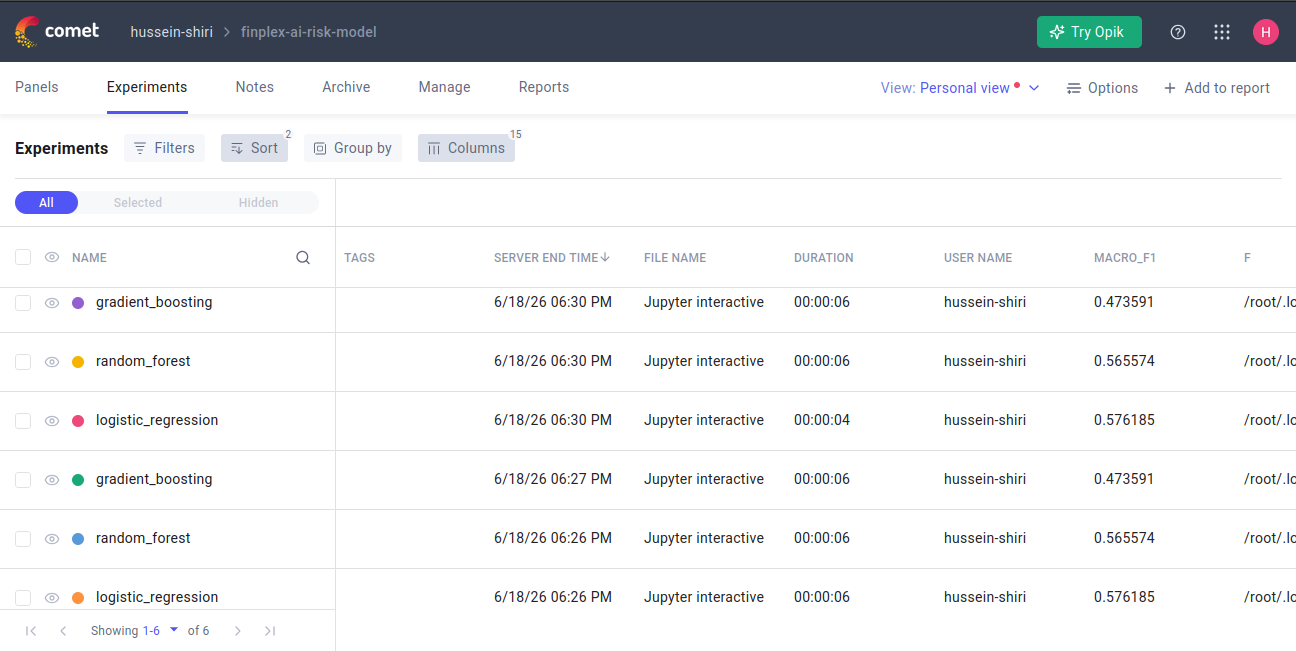

Upload the screenshot image from Comet ML.


Saving Screenshot From 2026-06-18 18-45-09.png to Screenshot From 2026-06-18 18-45-09.png
Saved screenshot: /content/artifacts/risk_model/mlflow_online_results_screenshot.png


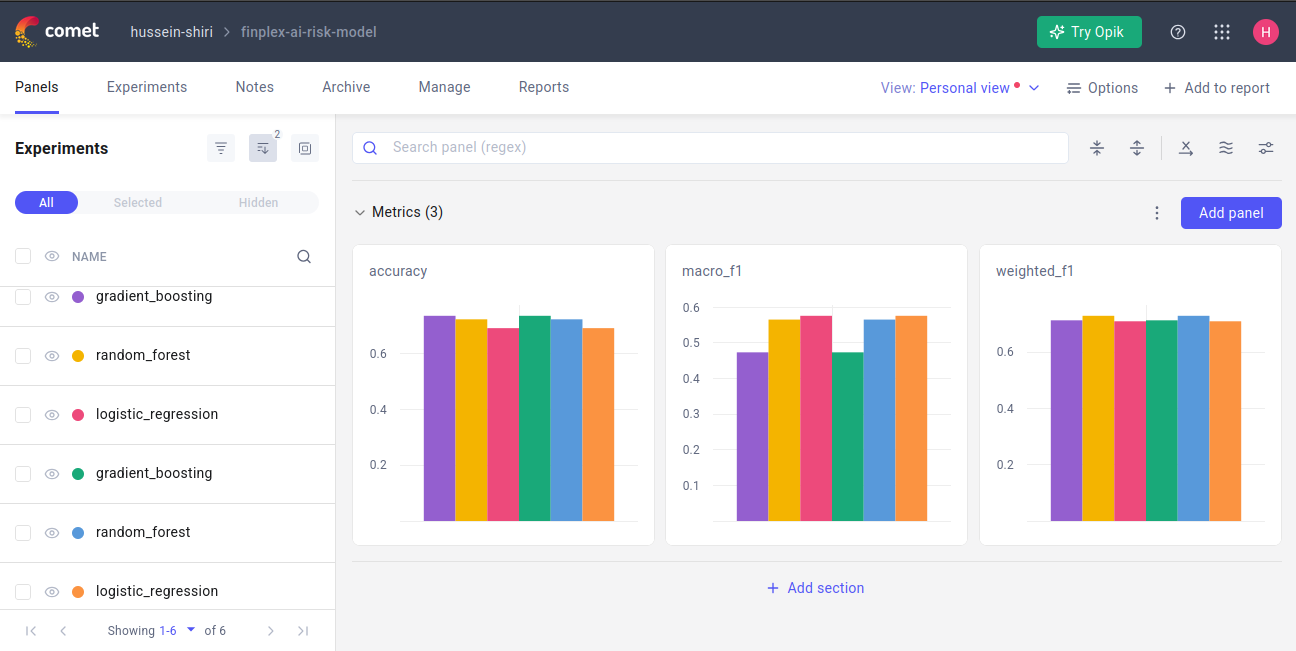

In [27]:
screenshot_path = ARTIFACTS_DIR / "mlflow_online_results_screenshot.png"

try:
    from google.colab import files

    print("Upload the screenshot image from Comet ML.")
    uploaded = files.upload()

    image_files = [
        filename
        for filename in uploaded
        if filename.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if image_files:
        uploaded_image_name = image_files[0]
        screenshot_path.write_bytes(uploaded[uploaded_image_name])

        print("Saved screenshot:", screenshot_path)
        display(DisplayImage(filename=str(screenshot_path)))

    else:
        print("No image file was uploaded.")

except Exception as exc:
    print("Screenshot upload is optional.")
    print(exc)

## 23. Create Downloadable Risk Model Artifact Package

This package contains:

- trained risk model
- model metadata
- feature schema
- evaluation report
- confusion matrix
- feature importance
- new uploaded invoice predictions
- model card
- optional online tracking screenshot

In [28]:
artifact_package_dir = PROJECT_ROOT / "risk_model_artifact_package"

if artifact_package_dir.exists():
    shutil.rmtree(artifact_package_dir)

package_models_dir = artifact_package_dir / "models"
package_artifacts_dir = artifact_package_dir / "artifacts" / "risk_model"
package_seed_dir = artifact_package_dir / "data" / "seed"
package_docs_dir = artifact_package_dir / "docs"

for folder in [
    package_models_dir,
    package_artifacts_dir,
    package_seed_dir,
    package_docs_dir,
]:
    folder.mkdir(parents=True, exist_ok=True)

for source_path in [
    model_path,
    label_mapping_path,
    model_metadata_path,
    feature_schema_path,
]:
    shutil.copy2(source_path, package_models_dir / source_path.name)

artifact_files = [
    results_summary_path,
    confusion_matrix_path,
    feature_importance_path,
    feature_importance_plot_path,
    eval_report_path,
    new_invoice_predictions_path,
]

if screenshot_path.exists():
    artifact_files.append(screenshot_path)

for source_path in artifact_files:
    shutil.copy2(source_path, package_artifacts_dir / source_path.name)

for source_path in [
    risk_training_dataset_path,
    historical_invoices_path,
    historical_payments_path,
    crm_customers_path,
    new_uploaded_invoices_path,
]:
    shutil.copy2(source_path, package_seed_dir / source_path.name)

shutil.copy2(model_card_path, package_docs_dir / "MODEL_CARD.md")

artifact_zip_path = PROJECT_ROOT / "risk_model_artifacts.zip"

if artifact_zip_path.exists():
    artifact_zip_path.unlink()

shutil.make_archive(
    base_name=str(artifact_zip_path.with_suffix("")),
    format="zip",
    root_dir=artifact_package_dir,
)

print("Created artifact ZIP:", artifact_zip_path)

try:
    from google.colab import files

    files.download(str(artifact_zip_path))
except Exception:
    print("Download helper is only available in Google Colab.")

Created artifact ZIP: /content/risk_model_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 24. Final Notes

This notebook trained the Finplex AI late-payment risk model using historical ERP/CRM behavior.

The important design is:

- the new uploaded invoice is not already known by ERP;
- OCR extracts the customer and invoice details;
- customer history is retrieved from CRM/ERP seed data;
- the risk model predicts late-payment risk based on previous behavior.

This supports the complete Finplex AI flow:

new invoice upload
→ extraction
→ customer matching
→ historical ERP/CRM lookup
→ risk prediction
→ compliant follow-up draft
→ human approval

The trained model artifact can later be loaded by the model-server endpoint `/score-risk`.